In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import datetime as dt
import glob
import numpy as np
import cartopy.crs as ccrs

In [23]:
def plot_mslp(time,ax,lon,lat,cbar=False):
    #lon1 = 112; lat1 = -44.5; lon2 = 156.5; lat2 = -10
    lon1 = 130; lat1 = -44.5; lon2 = 156.5; lat2 = -15

    f = xr.open_dataset(glob.glob("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_"\
                            +time.strftime("%Y%m")+"*.nc")[0]).sel({"time":time.replace(minute=0)})
    f=f.sel({"lon":slice(lon1,lon2), "lat":slice(lat2,lat1)})

    f2=xr.open_dataset(glob.glob("/g/data/rt52/era5/single-levels/reanalysis/msl/"+time.strftime("%Y")+"/msl_era5_oper_sfc_"+time.strftime("%Y%m")+"*.nc")[0])\
                       .sel({"time":time.replace(minute=0)})
    f2=f2.sel({"longitude":slice(lon1,lon2), "latitude":slice(lat2,lat1)})
    
    fu=xr.open_dataset(glob.glob("/g/data/rt52/era5/single-levels/reanalysis/10u/"+time.strftime("%Y")+"/10u_era5_oper_sfc_"+time.strftime("%Y%m")+"*.nc")[0])\
                   .sel({"time":time.replace(minute=0)}).sel({"longitude":slice(lon1,lon2), "latitude":slice(lat2,lat1)})
    fv=xr.open_dataset(glob.glob("/g/data/rt52/era5/single-levels/reanalysis/10v/"+time.strftime("%Y")+"/10v_era5_oper_sfc_"+time.strftime("%Y%m")+"*.nc")[0])\
                   .sel({"time":time.replace(minute=0)}).sel({"longitude":slice(lon1,lon2), "latitude":slice(lat2,lat1)})

    c=xr.plot.contourf(f["pwat"] * 25.4, cmap=plt.get_cmap("PuBuGn"),levels=[0,10,20,30,40,50,60,70],add_labels=False,add_colorbar=False, ax=ax)
    xr.plot.contour(f2["msl"]/100, levels=np.arange(980,1044,2),add_labels=False, colors=["k"], ax=ax, linewidths=1.5)
    plt.title(time)
    if cbar:
        cx=plt.axes([0.2,0.07,0.6,0.02])
        cb=plt.colorbar(c,cax=cx,orientation="horizontal")
        cb.set_label("Precipitable water (mm)")
    ax.coastlines(color="white",lw=2,alpha=1)
    
    x,y = np.meshgrid(fu.longitude.values, fv.latitude.values)
    xr.Dataset({"u":fu["u10"], "v":fv["v10"]}).coarsen({"latitude":5, "longitude":5},boundary="trim").mean().plot.quiver(
        x="longitude",y="latitude",u="u",v="v",ax=ax)
    
    ax.plot(lon,lat,ms=20,marker="*",mec=None,color="tab:red")
    
    g=ax.gridlines(draw_labels=True)
    g.top_labels=False
    g.right_labels=False

    #print(f,f2,fu,fv)

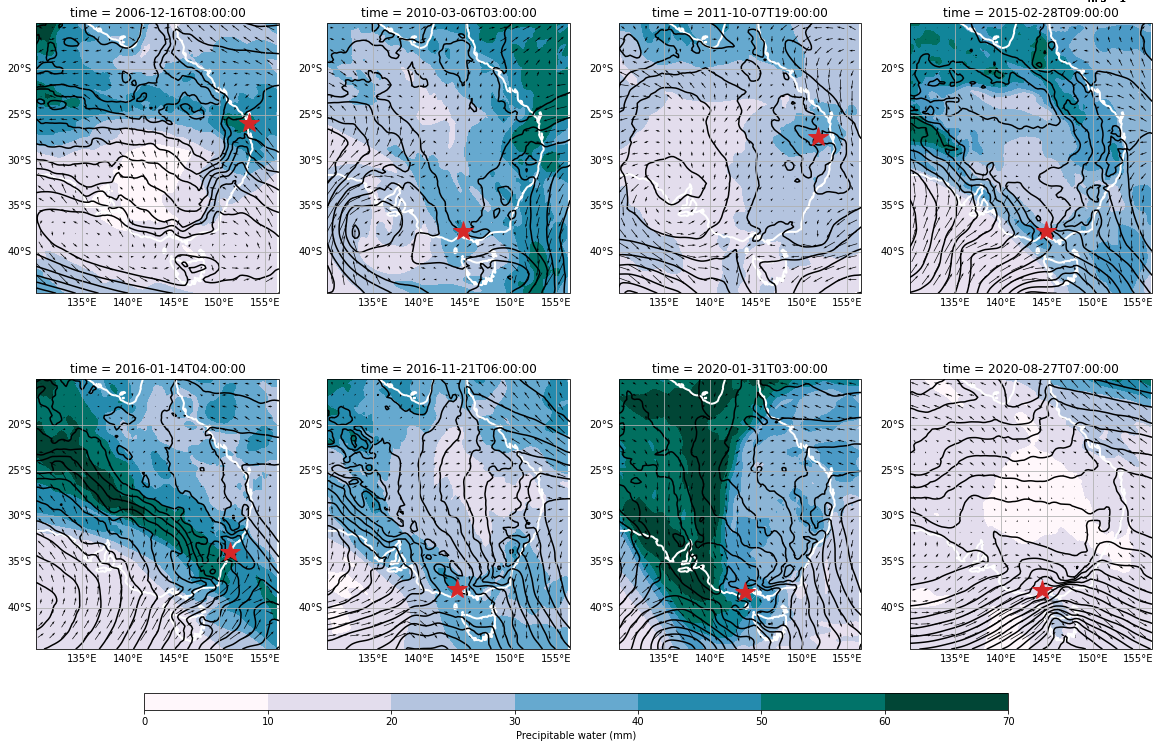

In [24]:
dets = [\
        {"lat":-25.9319, "lon":153.1906, "time" : [dt.datetime(2006,12,16,8,1)], "rid":"8", "title":"a) Double Island Point: 2006-12-16 08:01 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2010,3,6,3,24)], "rid":"2", "title":"b) Melbourne: 2010-03-06 03:24 UTC"},\
        {"lat":-27.4034, "lon":151.7413, "time" : [dt.datetime(2011,10,7,19,21)], "rid":"50", "title":"c) Oakey: 2011-10-07 19:21 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2015,2,28,9,24)], "rid":"2", "title":"d) Melbourne: 2015-02-28 09:24 UTC"},\
        {"lat":-33.9465, "lon":151.1731, "time" : [dt.datetime(2016,1,14,4,19)], "rid":"71", "title":"e) Sydney: 2016-01-14 04:19 UTC"},\
        {"lat":-37.9075, "lon":144.1303, "time" : [dt.datetime(2016,11,21,6,1)], "rid":"2", "title":"f) Melbourne: 2016-11-21 06:01 UTC" },\
        {"lat":-38.2332, "lon":143.7924, "time" : [dt.datetime(2020,1,31,3,42)], "rid":"2", "title":"g) Cressy: 2020-01-31 03:42 UTC"},\
        {"lat":-38.0288, "lon":144.4783, "time" : [dt.datetime(2020,8,27,7,12)], "rid":"2", "title":"h) Melbourne: 2020-08-27 07:12 UTC"},\
       ]
plt.figure(figsize=[20,12])
cnt=1
for t in dets:
    ax=plt.subplot(2,4,cnt,projection=ccrs.PlateCarree())
    if cnt==8:
        plot_mslp(t["time"][0],ax,t["lon"],t["lat"],True)
    else:
        plot_mslp(t["time"][0],ax,t["lon"],t["lat"])
    cnt=cnt+1


In [191]:
plt.plot?

Signature: plt.plot(*args, scalex=True, scaley=True, data=None, **kwargs)
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yield identical results:

>>> plot(x, y, 'go--', linewidth=2, markersize=12)
>>> plot(x, y,

<xarray.Dataset>
Dimensions:    (longitude: 1440, latitude: 721, time: 744)
Coordinates:
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float32 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 1979-01-01 ... 1979-01-31T23:00:00
Data variables:
    u10        (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2020-10-04 20:17:55 UTC+1100 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis 10m_u_component_of_wind 19790...